# CSI 4142 Assignment 4

### Group 90
| Name          | Student Number    | Group |
|:-------------:|:-----------------:|------:|
| Arda Barak    | 300129340         | 90    |
| Quoc Dat Phung| 300164087         | 90    |

In [1]:
try:
  import pandas as pd
  import numpy as np
  import seaborn as sns
  import matplotlib.pyplot as plt
  import Levenshtein
  from sklearn.cluster import KMeans
  from sklearn.cluster import DBSCAN
  from sklearn.preprocessing import StandardScaler
  from sklearn.preprocessing import MinMaxScaler
  from sklearn.metrics import mean_squared_error
  from scipy.sparse.linalg import svds

except:
  %pip install python-Levenshtein
  %pip install pandas
  %pip install matplotlib
  %pip install seaborn
  %pip install numpy

  import pandas as pd
  import numpy as np
  import seaborn as sns
  import matplotlib.pyplot as plt
  import Levenshtein
  from sklearn.cluster import KMeans
  from sklearn.cluster import DBSCAN
  from sklearn.preprocessing import StandardScaler
  from sklearn.preprocessing import MinMaxScaler
  from scipy.sparse.linalg import svds
  from sklearn.metrics import mean_squared_error


np.random.seed(42)

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 12.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: matplotlib in c:\users\arda\appdata\local\programs\python\python311\lib\site-packages (3.9.2)




[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import pandas as pd
# import numpy as np
# np.random.seed(42)
# import seaborn as sns
# import matplotlib.pyplot as plt

In [ ]:
# ! pip install python-Levenshtein # For Edit Distance Similarity
# import Levenshtein

In [ ]:
# from sklearn.cluster import KMeans
# from sklearn.cluster import DBSCAN
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler

# Dataset 1: Anime Recommendations Database
#### Authors: CooperUnion, Basement Dweller
#### Description: This data set contains information on user preference data from 73,516 users on 12,294 anime. Each user is able to add anime to their completed list and give it a rating and this data set is a compilation of those ratings

File 1: Anime.csv (12294 rows, 7 columns)</br>

anime_id (int) - myanimelist.net's unique id identifying an anime.</br>
name (str) - full name of anime.</br>
genre (str)- comma separated list of genres for this anime.</br>
type (str)- movie, TV, OVA, etc.</br>
episodes (int)- how many episodes in this show. (1 if movie).</br>
rating (float)- average rating out of 10 for this anime.</br>
members (int)- number of community members that are in this anime's "group".</br></br>

File 2: Rating.csv (7813737 rows, 3 columns) </br>
user_id (int)- non identifiable randomly generated user id.</br>
anime_id (int)- the anime that this user has rated.</br>
rating (int)- rating out of 10 this user has assigned (-1 if the user watched it but didn't assign a rating).</br>

In [2]:
# https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database?select=anime.csv
url_anime = 'https://raw.githubusercontent.com/Quoc-Dat-Phung/CSI4142_A4/refs/heads/main/anime.csv'
url_rating = 'https://raw.githubusercontent.com/Quoc-Dat-Phung/CSI4142_A4/refs/heads/main/rating.csv'

In [3]:
df_anime = pd.read_csv(url_anime)
df_anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [4]:
df_rating = pd.read_csv(url_rating)
df_rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [5]:
df_anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [6]:
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


# Preparing the Data

Dropping Exact Duplicate Rows

In [7]:
df_anime = df_anime.drop_duplicates()
df_anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [8]:
df_rating = df_rating.drop_duplicates()
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7813736 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 238.5 MB


Presence Check: Verify if each column has missing values

In [9]:
def check_column_for_missing_values(df):
  for column in df.columns:
    print(f"'{column}' has {df[column].isna().sum()} missing values. ")

In [10]:
check_column_for_missing_values(df_rating)

'user_id' has 0 missing values. 
'anime_id' has 0 missing values. 
'rating' has 0 missing values. 


In [11]:
check_column_for_missing_values(df_anime)

'anime_id' has 0 missing values. 
'name' has 0 missing values. 
'genre' has 62 missing values. 
'type' has 25 missing values. 
'episodes' has 0 missing values. 
'rating' has 230 missing values. 
'members' has 0 missing values. 


In [12]:
# Impute rating with median
median_value = int(df_anime["rating"].median())
df_anime["rating"] = df_anime["rating"].fillna(median_value).astype(int)
check_column_for_missing_values(df_anime)

'anime_id' has 0 missing values. 
'name' has 0 missing values. 
'genre' has 62 missing values. 
'type' has 25 missing values. 
'episodes' has 0 missing values. 
'rating' has 0 missing values. 
'members' has 0 missing values. 


In [13]:
# Missing genre/type is a concern (because genre is a list of strings). There are over 10,000 rows. Let's drop rows with missing values
df_anime = df_anime.dropna()
check_column_for_missing_values(df_anime)

'anime_id' has 0 missing values. 
'name' has 0 missing values. 
'genre' has 0 missing values. 
'type' has 0 missing values. 
'episodes' has 0 missing values. 
'rating' has 0 missing values. 
'members' has 0 missing values. 


Data Type Check and Fixing

In [14]:
df_rating.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7813736 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 238.5 MB


In [15]:
df_anime.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12210 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   anime_id  12210 non-null  int64 
 1   name      12210 non-null  object
 2   genre     12210 non-null  object
 3   type      12210 non-null  object
 4   episodes  12210 non-null  object
 5   rating    12210 non-null  int32 
 6   members   12210 non-null  int64 
dtypes: int32(1), int64(2), object(4)
memory usage: 715.4+ KB


In [16]:
# Here, episodes should be int
# Identify rows where 'episodes' is not numeric
df_anime[~df_anime["episodes"].str.isnumeric()]

,anime_id,name,genre,type,episodes,rating,members
74,21,One Piece,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",TV,Unknown,8,504862
252,235,Detective Conan,"Adventure, Comedy, Mystery, Police, Shounen",TV,Unknown,8,114702
615,1735,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,Unknown,7,533578
991,966,Crayon Shin-chan,"Comedy, Ecchi, Kids, School, Shounen, Slice of...",TV,Unknown,7,26267
1021,33157,Tanaka-kun wa Itsumo Kedaruge Specials,"Comedy, School, Slice of Life",Special,Unknown,7,5400
...,...,...,...,...,...,...,...
12265,34361,Kyonyuu Reijou MC Gakuen,Hentai,OVA,Unknown,6,205
12274,34492,Nuki Doki! Tenshi to Akuma no Sakusei Battle -...,Hentai,OVA,Unknown,6,392
12280,34312,Saimin Class,Hentai,OVA,Unknown,6,240
12282,34388,Shikkoku no Shaga The Animation,Hentai,OVA,Unknown,6,195


In [17]:
# Replace "Unknown" and other non numeric values with NaN
df_anime["episodes"] = pd.to_numeric(df_anime["episodes"], errors="coerce")
# Compute the median
median_value = df_anime["episodes"].median()
# Replace NaN values with the median
df_anime["episodes"] = df_anime["episodes"].fillna(median_value)
df_anime["episodes"] = df_anime["episodes"].astype(int)
print(df_anime.info())

<class 'pandas.core.frame.DataFrame'>
Index: 12210 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   anime_id  12210 non-null  int64 
 1   name      12210 non-null  object
 2   genre     12210 non-null  object
 3   type      12210 non-null  object
 4   episodes  12210 non-null  int32 
 5   rating    12210 non-null  int32 
 6   members   12210 non-null  int64 
dtypes: int32(2), int64(2), object(3)
memory usage: 667.7+ KB
None


Range check

In [18]:
# I see that the minimum rating is 1 and max is 10
df_anime.describe()

,anime_id,episodes,rating,members
count,12210.000000,12210.000000,12210.000000,1.221000e+04
mean,13936.486486,12.164128,6.001229,1.817871e+04
std,11398.045316,46.394448,1.051035,5.498978e+04
min,1.000000,1.000000,1.000000,5.000000e+00
25%,3460.250000,1.000000,5.000000,2.290000e+02
50%,10168.500000,2.000000,6.000000,1.571000e+03
75%,24442.500000,12.000000,7.000000,9.530000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


In [19]:
# In the dataset description, the author says that for rating.csv, rating=-1 if user didn't rate. (However in anime.csv, the rating is between 1 and 10)
df_rating.describe()

,user_id,anime_id,rating
count,7.813736e+06,7.813736e+06,7.813736e+06
mean,3.672796e+04,8.909071e+03,6.144029e+00
std,2.099795e+04,8.883950e+03,3.727801e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


Uniqueness Check

In [20]:
# IDs should be unique
# Return True if there are duplicates
df_anime['anime_id'].duplicated().any()

False

In [21]:
# In anime.csv, anime_id must be unique
# But in rating.csv, user id does not have to be unique because a user can rate many movies.
df_rating['user_id'].duplicated().any()

True

In [22]:
df_rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


EDA and Outlier Detection

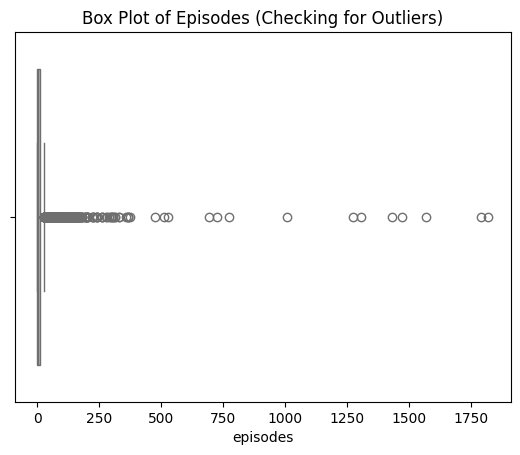

In [23]:
# There are short/long series so outliers for episodes should not be removed
sns.boxplot(x=df_anime["episodes"], color="skyblue")
plt.title("Box Plot of Episodes (Checking for Outliers)")
plt.show()

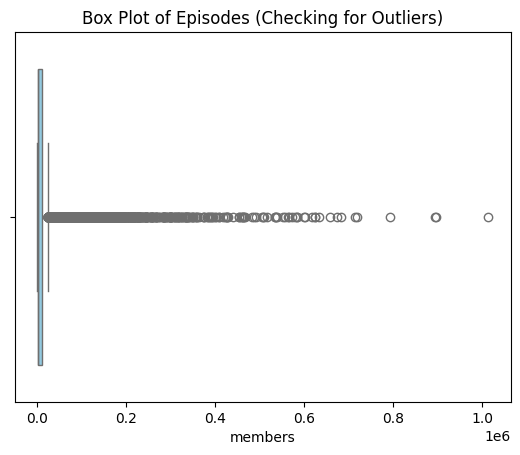

In [24]:
# There are popular series so outliers for members should not be removed
sns.boxplot(x=df_anime["members"], color="skyblue")
plt.title("Box Plot of Episodes (Checking for Outliers)")
plt.show()

Encoding column "type"

In [25]:
df_anime["type"].value_counts()

type
TV         3777
OVA        3310
Movie      2306
Special    1674
ONA         655
Music       488
Name: count, dtype: int64

In [26]:
# Backup the 'type' column before dropping
type_copy = df_anime["type"]
type_copy.head()

0    Movie
1       TV
2       TV
3       TV
4       TV
Name: type, dtype: object

In [27]:
# Drop the original 'type' column
df_anime = df_anime.drop(columns=["type"])
df_anime.head()

,anime_id,name,genre,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",1,9,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",64,9,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",51,9,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",24,9,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",51,9,151266


In [28]:
# Apply One-Hot Encoding to the 'type' column
df_anime_type_encoded = pd.get_dummies(type_copy, prefix="type").astype(int)
df_anime_type_encoded.head()

,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,1,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


In [29]:
# Concatenate the encoded columns back to df_anime
df_anime = pd.concat([df_anime, df_anime_type_encoded], axis=1)
df_anime.head()

,anime_id,name,genre,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",1,9,200630,1,0,0,0,0,0
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",64,9,793665,0,0,0,0,0,1
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",51,9,114262,0,0,0,0,0,1
3,9253,Steins;Gate,"Sci-Fi, Thriller",24,9,673572,0,0,0,0,0,1
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",51,9,151266,0,0,0,0,0,1


Encoding column "genre"

In [30]:
# Extract all unique genres
all_genres = set()
for genre_list in df_anime["genre"]:
    genres = genre_list.split(", ")  # Split genres by comma and space
    all_genres.update(genres)

print(all_genres)

{'Seinen', 'Martial Arts', 'Game', 'Yuri', 'Mecha', 'Shounen', 'Parody', 'Sci-Fi', 'Psychological', 'Shoujo Ai', 'Hentai', 'Magic', 'Harem', 'Dementia', 'Adventure', 'Thriller', 'Romance', 'Fantasy', 'Samurai', 'Military', 'Sports', 'Space', 'Yaoi', 'Shounen Ai', 'Ecchi', 'Action', 'Kids', 'Slice of Life', 'Comedy', 'Historical', 'Shoujo', 'Police', 'Drama', 'Super Power', 'Music', 'Horror', 'Demons', 'Supernatural', 'Vampire', 'Cars', 'Josei', 'School', 'Mystery'}


In [31]:
# Create those new columns
for genre in all_genres:
   # Initialize columns with 0
    df_anime[f"genre_{genre}"] = 0

df_anime.head()

,anime_id,name,genre,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,...,genre_Super Power,genre_Music,genre_Horror,genre_Demons,genre_Supernatural,genre_Vampire,genre_Cars,genre_Josei,genre_School,genre_Mystery
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",1,9,200630,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",64,9,793665,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",51,9,114262,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9253,Steins;Gate,"Sci-Fi, Thriller",24,9,673572,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",51,9,151266,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
# Iterate through each row and update values accordingly
for index, row in df_anime.iterrows():
    genres = row["genre"].split(", ")
    for genre in genres:
        df_anime.at[index, f"genre_{genre}"] = 1

# Drop the original "genre" column since it's now encoded
df_anime.drop(columns=["genre"], inplace=True)

df_anime.head()

,anime_id,name,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,type_Special,...,genre_Super Power,genre_Music,genre_Horror,genre_Demons,genre_Supernatural,genre_Vampire,genre_Cars,genre_Josei,genre_School,genre_Mystery
0,32281,Kimi no Na wa.,1,9,200630,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,5114,Fullmetal Alchemist: Brotherhood,64,9,793665,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28977,Gintama°,51,9,114262,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9253,Steins;Gate,24,9,673572,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9969,Gintama&#039;,51,9,151266,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


We should not scale the data with log transformation, minmax scaling, or standardization because it makes the data invalid (e.g floats for "episodes" and "members", even if converted to int there are lots of 0 and 1 values. I will just keep it the same)

# Study 1 – Similarity measures

### Attribute 1: "Members"
Similarity Measure: Euclidian Distance </br>
sqrt((x-y)^2) = |x-y| (in 1D) </br>
Example: "Find anime with a similar number of members (views) to Death Note"</br>

In [40]:
target_title = "Death Note"
# Extract the number of members for a specific anime
target_members = df_anime[df_anime['name'] == target_title]['members'].values[0]
print(target_members)

1013917


In [41]:
# Avoid comparing with itself
df_anime_filtered = df_anime[df_anime['name'] != target_title].copy()

# Calculate Euclidean distance:
# Subtracts the number of members of the target anime from each anime's members count.
# Takes the absolute value of each difference. This gives the Euclidean distance in 1D

# For example, "Death Note" has 2,345,678 members.
# If another anime has 2,350,000, the calculation is: abs(2,350,000 - 2,345,678) = 4,322
df_anime_filtered['euclidean_distance'] = (df_anime_filtered['members'] - target_members).abs()
df_anime_filtered[['name', 'members', 'euclidean_distance']].head()

,name,members,euclidean_distance
0,Kimi no Na wa.,200630,813287
1,Fullmetal Alchemist: Brotherhood,793665,220252
2,Gintama°,114262,899655
3,Steins;Gate,673572,340345
4,Gintama&#039;,151266,862651


In [42]:
# Get Top 10 most similar
top_10_similar = df_anime_filtered.sort_values('euclidean_distance').head(10)

# Show some useful columns
# Smallest distance = most similar in terms of member count (popularity)
top_10_similar[['name', 'members', 'euclidean_distance']]

,name,members,euclidean_distance
86,Shingeki no Kyojin,896229,117688
804,Sword Art Online,893100,120817
1,Fullmetal Alchemist: Brotherhood,793665,220252
159,Angel Beats!,717796,296121
19,Code Geass: Hangyaku no Lelouch,715151,298766
841,Naruto,683297,330620
3,Steins;Gate,673572,340345
445,Mirai Nikki (TV),657190,356727
131,Toradora!,633817,380100
582,Bleach,624055,389862


### Attribute 2: "Genre"
Similarity Measure: Jaccard Similarity </br>
Example: "Find anime with a similar genre to Death Note"</br>

In [43]:
# Step 1: Get all genre column names
genre_columns = []
for col in df_anime.columns:
    if col.startswith('genre_'):
        genre_columns.append(col)
print(genre_columns)

['genre_Seinen', 'genre_Martial Arts', 'genre_Game', 'genre_Yuri', 'genre_Mecha', 'genre_Shounen', 'genre_Parody', 'genre_Sci-Fi', 'genre_Psychological', 'genre_Shoujo Ai', 'genre_Hentai', 'genre_Magic', 'genre_Harem', 'genre_Dementia', 'genre_Adventure', 'genre_Thriller', 'genre_Romance', 'genre_Fantasy', 'genre_Samurai', 'genre_Military', 'genre_Sports', 'genre_Space', 'genre_Yaoi', 'genre_Shounen Ai', 'genre_Ecchi', 'genre_Action', 'genre_Kids', 'genre_Slice of Life', 'genre_Comedy', 'genre_Historical', 'genre_Shoujo', 'genre_Police', 'genre_Drama', 'genre_Super Power', 'genre_Music', 'genre_Horror', 'genre_Demons', 'genre_Supernatural', 'genre_Vampire', 'genre_Cars', 'genre_Josei', 'genre_School', 'genre_Mystery']


In [44]:
# Step 2: Choose target anime
target_title = "Death Note"
target_row = df_anime[df_anime['name'] == target_title]
target_row

,anime_id,name,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,type_Special,...,genre_Super Power,genre_Music,genre_Horror,genre_Demons,genre_Supernatural,genre_Vampire,genre_Cars,genre_Josei,genre_School,genre_Mystery
40,1535,Death Note,37,8,1013917,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [45]:
# Get the genres (represented by a vector of 0s and 1s)
target_genres = target_row[genre_columns].values[0]
target_genres

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
      dtype=int64)

In [46]:
# Step 3: Define Jaccard similarity for binary vectors (genre columns)
def jaccard_binary(row):
    # Get the genre values for the current anime (0 or 1 for each genre)
    current_genres = row[genre_columns].values

    # Calculate how many genres are shared (intersection)
    intersection = 0
    for i in range(len(current_genres)):
        if current_genres[i] == 1 and target_genres[i] == 1:
            intersection += 1

    # Calculate how many genres are in either anime (union)
    union = 0
    for i in range(len(current_genres)):
        if current_genres[i] == 1 or target_genres[i] == 1:
            union += 1

    # Return the Jaccard similarity (handle divide-by-zero just in case)
    if union == 0:
        return 0
    else:
        return intersection / union

In [47]:
# Step 4: Avoid comparing with itself
df_anime_filtered = df_anime[df_anime['name'] != target_title].copy()
df_anime_filtered.head()

,anime_id,name,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,type_Special,...,genre_Super Power,genre_Music,genre_Horror,genre_Demons,genre_Supernatural,genre_Vampire,genre_Cars,genre_Josei,genre_School,genre_Mystery
0,32281,Kimi no Na wa.,1,9,200630,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,5114,Fullmetal Alchemist: Brotherhood,64,9,793665,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28977,Gintama°,51,9,114262,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9253,Steins;Gate,24,9,673572,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9969,Gintama&#039;,51,9,151266,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
# Step 5: Compute similarity
df_anime_filtered['jaccard_similarity'] = df_anime_filtered.apply(jaccard_binary, axis=1)
df_anime_filtered[['name', 'jaccard_similarity']].head()

,name,jaccard_similarity
0,Kimi no Na wa.,0.125000
1,Fullmetal Alchemist: Brotherhood,0.000000
2,Gintama°,0.000000
3,Steins;Gate,0.166667
4,Gintama&#039;,0.000000


In [49]:
# Step 6: Show Top 10
# Note: "Death Note" and "Death Note Rewrite" are different.
top_10_jaccard = df_anime_filtered.sort_values('jaccard_similarity', ascending=False).head(10)
top_10_jaccard[['name', 'jaccard_similarity']]

,name,jaccard_similarity
778,Death Note Rewrite,1.000000
981,Mousou Dairinin,0.833333
144,Higurashi no Naku Koro ni Kai,0.800000
1383,Higurashi no Naku Koro ni Rei,0.666667
334,Higurashi no Naku Koro ni,0.666667
833,Jigoku Shoujo Mitsuganae,0.600000
2691,Yakushiji Ryouko no Kaiki Jikenbo,0.600000
10785,"Yakushiji Ryouko no Kaiki Jikenbo: Hamachou, V...",0.600000
6323,Saint Luminous Jogakuin,0.600000
445,Mirai Nikki (TV),0.571429


### Attribute 3: "Episodes"
Similarity Measure: Manhattan </br>
(Note, in 1D data points, Euclidean = Manhattan) </br>
Example: "Find anime with a similar number of episodes to Death Note"</br>

In [50]:
# Step 1: Pick the target anime
target_title = "Death Note"
target_episodes = df_anime[df_anime['name'] == target_title]['episodes'].values[0]
print(target_episodes)

37


In [51]:
# Step 2: Filter out the target itself
df_anime_filtered = df_anime[df_anime['name'] != target_title].copy()
df_anime_filtered.head()

,anime_id,name,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,type_Special,...,genre_Super Power,genre_Music,genre_Horror,genre_Demons,genre_Supernatural,genre_Vampire,genre_Cars,genre_Josei,genre_School,genre_Mystery
0,32281,Kimi no Na wa.,1,9,200630,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,5114,Fullmetal Alchemist: Brotherhood,64,9,793665,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28977,Gintama°,51,9,114262,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9253,Steins;Gate,24,9,673572,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9969,Gintama&#039;,51,9,151266,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
# Step 3: Compute Manhattan Distance
df_anime_filtered['manhattan_distance'] = (df_anime_filtered['episodes'] - target_episodes).abs()
df_anime_filtered[['name', 'episodes', 'manhattan_distance']].head()

,name,episodes,manhattan_distance
0,Kimi no Na wa.,1,36
1,Fullmetal Alchemist: Brotherhood,64,27
2,Gintama°,51,14
3,Steins;Gate,24,13
4,Gintama&#039;,51,14


In [53]:
# Step 4: Show Top 10 with closest episode count
top_10_episodes = df_anime_filtered.sort_values('manhattan_distance').head(10)
top_10_episodes[['name', 'episodes', 'manhattan_distance']]

,name,episodes,manhattan_distance
1146,Plawres Sanshirou,37,0
5230,Tanken Driland,37,0
10272,Shounen Ashibe (TV),37,0
10052,Qin Shiming Yue Zhi: Wanli Changcheng,37,0
2156,Mini Van,37,0
3630,Miyuki,37,0
6528,Cream Lemon: Lemon Angel,37,0
1446,Future GPX Cyber Formula,37,0
5592,Kikou Keisatsu Metal Jack,37,0
2071,Danball Senki Wars,37,0


### Attribute 4: "Title"
Similarity Measure: Levenshtein distance </br>
It’s the minimum number of single-character edits (insertions, deletions, or substitutions) required to change one string into another. </br>
Example: "Get the Top 10 titles with smallest edit distance (most similar) to 'Death Note'."</br>

In [54]:
# Step 1: Pick the target title
target_title = "Death Note"

In [55]:
# Step 2: Filter out the target anime
df_anime_filtered = df_anime[df_anime['name'] != target_title].copy()

In [56]:
def compute_edit_distance(title):
    return Levenshtein.distance(title, target_title)

In [57]:
# Step 3: Compute edit distance for each title
df_anime_filtered['edit_distance'] = df_anime_filtered['name'].apply(compute_edit_distance)
df_anime_filtered[['name', 'edit_distance']].head()

,name,edit_distance
0,Kimi no Na wa.,12
1,Fullmetal Alchemist: Brotherhood,25
2,Gintama°,9
3,Steins;Gate,8
4,Gintama&#039;,12


In [59]:
# Step 4: Get the Top 10 titles with smallest edit distance (most similar)
top_10_titles = df_anime_filtered.sort_values('edit_distance').head(10)
top_10_titles[['name', 'edit_distance']]

,name,edit_distance
11006,Hinako Note,5
199,Death Parade,5
3429,Dear Boys,5
8004,Dark Cat,6
8435,Dead World,6
5678,Dear Brave,6
12116,Deep Voice,6
7066,Beat Shot!!,6
11792,Dark Blue,6
11854,Leatherman,6


### Attribute 5: "Rating"
Similarity Measure: Euclidian Distance </br>
Example: "Find anime with a similar rating to Death Note"</br>

In [60]:
# Step 1: Get target anime's rating
target_title = "Death Note"
target_rating = df_anime[df_anime['name'] == target_title]['rating'].values[0]
print(target_rating)

8


In [61]:
# Step 2: Filter out the target
df_anime_filtered = df_anime[df_anime['name'] != target_title].copy()

In [62]:
# Step 3: Compute absolute difference (Manhattan in 1D)
df_anime_filtered['rating_distance'] = (df_anime_filtered['rating'] - target_rating).abs()
df_anime_filtered[['name', 'rating', 'rating_distance']]

,name,rating,rating_distance
0,Kimi no Na wa.,9,1
1,Fullmetal Alchemist: Brotherhood,9,1
2,Gintama°,9,1
3,Steins;Gate,9,1
4,Gintama&#039;,9,1
...,...,...,...
12289,Toushindai My Lover: Minami tai Mecha-Minami,4,4
12290,Under World,4,4
12291,Violence Gekiga David no Hoshi,4,4
12292,Violence Gekiga Shin David no Hoshi: Inma Dens...,4,4


In [63]:
# Step 4: Get Top 10 most similar by rating
top_10_rating = df_anime_filtered.sort_values('rating_distance').head(10)
top_10_rating[['name', 'rating', 'rating_distance']]

,name,rating,rating_distance
502,Zoku Sayonara Zetsubou Sensei,8,0
403,Hanamonogatari,8,0
404,Kimi to Boku. 2,8,0
405,Ookiku Furikabutte,8,0
406,Ore Monogatari!!,8,0
407,Tamayura: Sotsugyou Shashin Part 4 - Ashita,8,0
408,Tekkon Kinkreet,8,0
409,There She Is!!,8,0
410,xxxHOLiC,8,0
411,Byousoku 5 Centimeter,8,0


# Study 2 – Clustering algorithms

**Outline:** </br>
Kmeans </br>
- k = 3 Members vs Rating </br>
- k = 3 Episodes vs Rating </br>
- k = 4 Members vs Rating </br>
- k = 4 Episodes vs Rating </br> </br>

DBScan </br>
- eps = 1, min = 1 Members vs Rating </br>
- eps = 1, min = 1 Episodes vs Rating </br>
- eps = 2, min = 2 Members vs Rating </br>
- eps = 2, min = 2 Episodes vs Rating </br>

### Kmeans with k = 3 Members vs Rating

In [64]:
# Prepare the data for clustering: Members and Rating
df_clustering = df_anime[['members', 'rating']].dropna()
df_clustering.head()

,members,rating
0,200630,9
1,793665,9
2,114262,9
3,673572,9
4,151266,9


In [65]:
# Run KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df_clustering['cluster'] = kmeans.fit_predict(df_clustering)
df_clustering['cluster'].head()

0    1
1    2
2    1
3    2
4    1
Name: cluster, dtype: int32

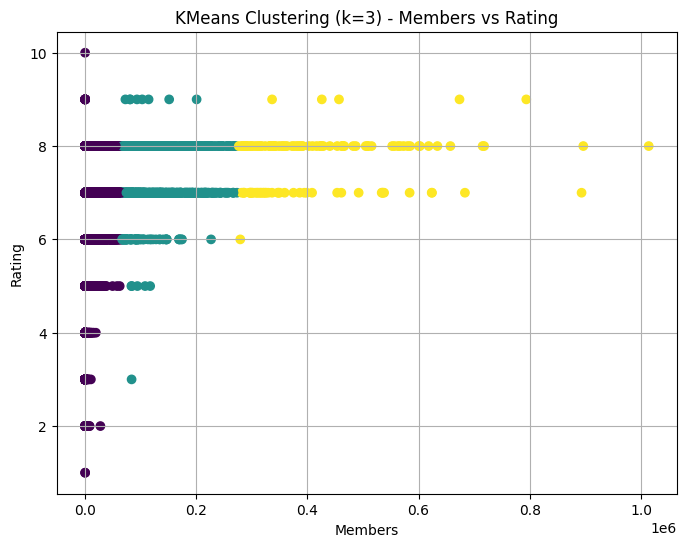

In [66]:
# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(df_clustering['members'], df_clustering['rating'], c=df_clustering['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=3) - Members vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_kmeans3_members_ratings = df_clustering.copy()

### Kmeans with k = 3 Episodes vs Rating

In [67]:
# Prepare data for clustering: Episodes vs Rating
df_clustering = df_anime[['episodes', 'rating']].dropna()
df_clustering.head()

,episodes,rating
0,1,9
1,64,9
2,51,9
3,24,9
4,51,9


In [68]:
# Run KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df_clustering['cluster'] = kmeans.fit_predict(df_clustering)

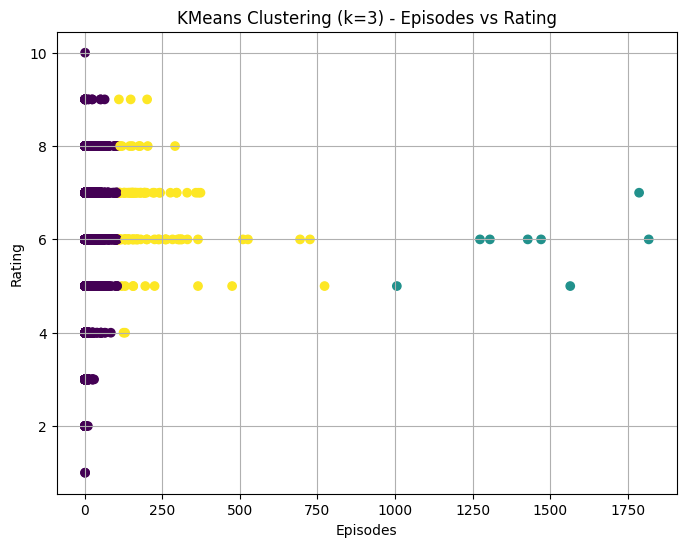

In [69]:
# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(df_clustering['episodes'], df_clustering['rating'], c=df_clustering['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=3) - Episodes vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_kmeans3_episodes_ratings = df_clustering.copy()

### Kmeans with k = 4 Members vs Rating

In [70]:
# Prepare the data for clustering: Members and Rating
df_clustering = df_anime[['members', 'rating']].dropna()
df_clustering.head()

,members,rating
0,200630,9
1,793665,9
2,114262,9
3,673572,9
4,151266,9


In [71]:
# Run KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering['cluster'] = kmeans.fit_predict(df_clustering)

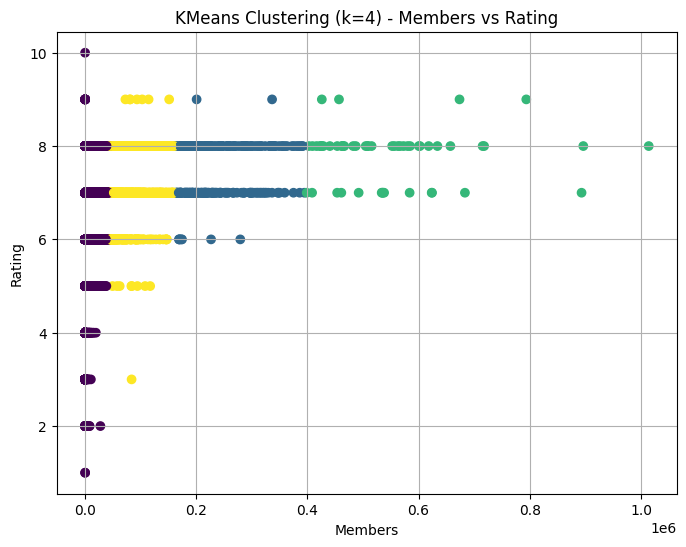

In [72]:
# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(df_clustering['members'], df_clustering['rating'], c=df_clustering['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=4) - Members vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_kmeans4_members_ratings = df_clustering.copy()

### Kmeans with k = 4 Episodes vs Rating

In [73]:
# Prepare data for clustering: Episodes and Rating
df_clustering = df_anime[['episodes', 'rating']].dropna()
df_clustering.head()

,episodes,rating
0,1,9
1,64,9
2,51,9
3,24,9
4,51,9


In [74]:
# Run KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering['cluster'] = kmeans.fit_predict(df_clustering)

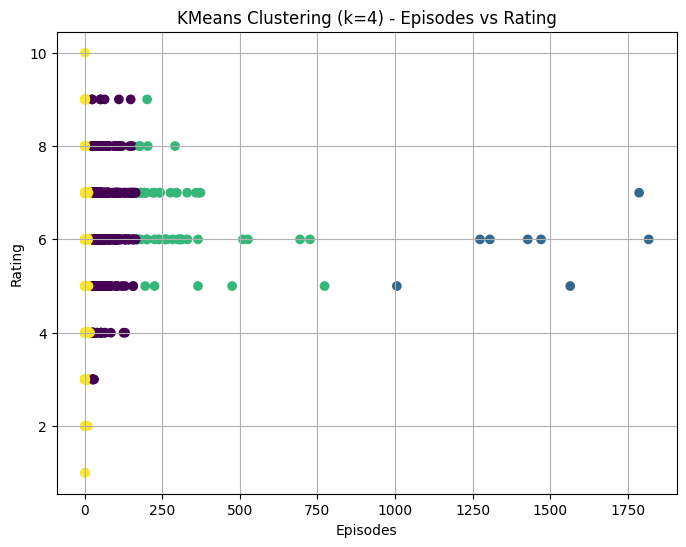

In [75]:
# Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(df_clustering['episodes'], df_clustering['rating'], c=df_clustering['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=4) - Episodes vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_kmeans4_episodes_ratings = df_clustering.copy()

### DBScan with eps = 1, min = 1 Members vs Rating

In [76]:
# Prepare data: Members vs Rating
df_dbscan = df_anime[['members', 'rating']].dropna()
df_dbscan.head()

,members,rating
0,200630,9
1,793665,9
2,114262,9
3,673572,9
4,151266,9


In [77]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_dbscan)

In [78]:
# Run DBSCAN with eps=3, min_samples=3
dbscan = DBSCAN(eps=1, min_samples=1)
df_dbscan['cluster'] = dbscan.fit_predict(X_scaled)

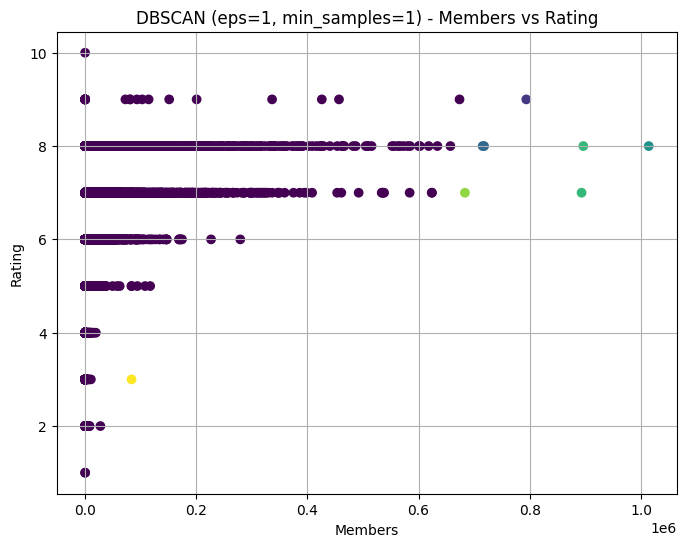

In [79]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_dbscan['members'], df_dbscan['rating'], c=df_dbscan['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=1, min_samples=1) - Members vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_dbscan_1_1_members_ratings = df_dbscan.copy()

### DBSCAN eps = 1, min = 1 Episodes vs Rating

In [80]:
# Prepare features
df_dbscan = df_anime[['episodes', 'rating']].dropna()
df_dbscan.head()

,episodes,rating
0,1,9
1,64,9
2,51,9
3,24,9
4,51,9


In [81]:
# Scale features
scaler = StandardScaler()
X_scaled_ep = scaler.fit_transform(df_dbscan)

In [82]:
# Run DBSCAN
dbscan = DBSCAN(eps=1, min_samples=1)
df_dbscan['cluster'] = dbscan.fit_predict(X_scaled_ep)

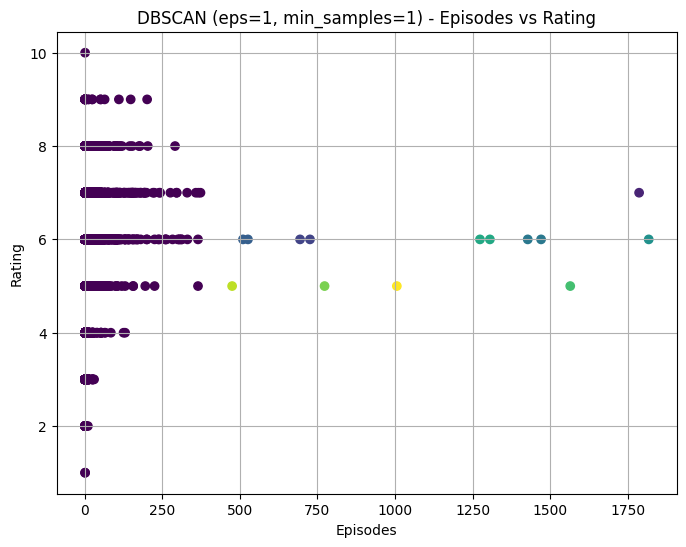

In [83]:
# Plot results
plt.figure(figsize=(8, 6))
plt.scatter(df_dbscan['episodes'], df_dbscan['rating'], c=df_dbscan['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=1, min_samples=1) - Episodes vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_dbscan_1_1_episodes_ratings = df_dbscan.copy()

### DBScan eps = 2, min = 2 Members vs Rating

In [84]:
# Prepare data: Members vs Rating
df_dbscan = df_anime[['members', 'rating']].dropna()
df_dbscan.head()

,members,rating
0,200630,9
1,793665,9
2,114262,9
3,673572,9
4,151266,9


In [85]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_dbscan)

In [86]:
# Run DBSCAN
dbscan = DBSCAN(eps=2, min_samples=2)
df_dbscan['cluster'] = dbscan.fit_predict(X_scaled)

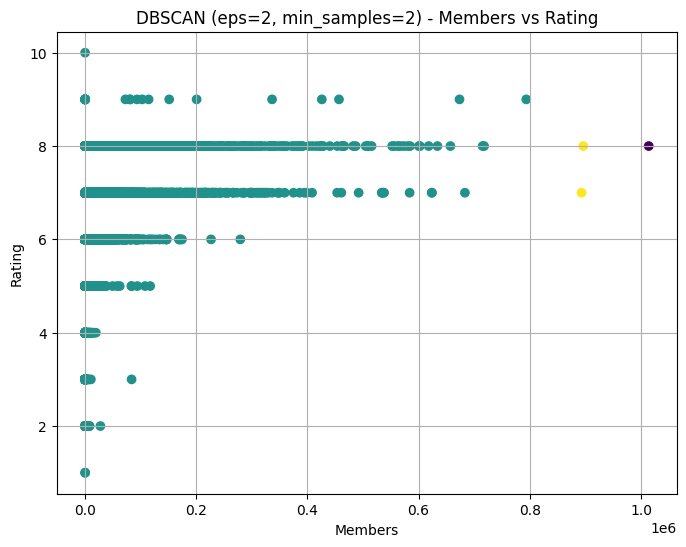

In [87]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_dbscan['members'], df_dbscan['rating'], c=df_dbscan['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=2, min_samples=2) - Members vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_dbscan_2_2_members_ratings = df_dbscan.copy()

### DBSCAN eps = 2, min = 2 Episodes vs Rating

In [88]:
# Prepare features
df_dbscan = df_anime[['episodes', 'rating']].dropna()
df_dbscan.head()

,episodes,rating
0,1,9
1,64,9
2,51,9
3,24,9
4,51,9


In [89]:
# Scale features
scaler = StandardScaler()
X_scaled_ep = scaler.fit_transform(df_dbscan)

In [90]:
# Run DBSCAN
dbscan = DBSCAN(eps=1, min_samples=1)
df_dbscan['cluster'] = dbscan.fit_predict(X_scaled_ep)

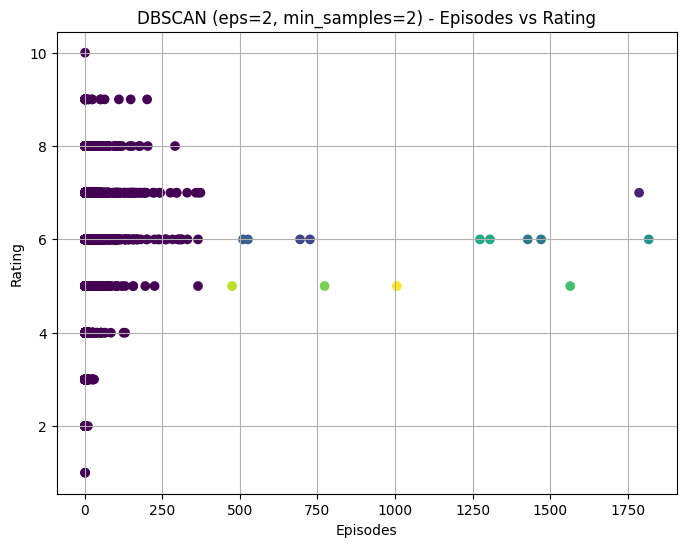

In [91]:
# Plot results
plt.figure(figsize=(8, 6))
plt.scatter(df_dbscan['episodes'], df_dbscan['rating'], c=df_dbscan['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=2, min_samples=2) - Episodes vs Rating")
plt.grid(True)
plt.show()

# Create copy
df_clustering_dbscan_2_2_episodes_ratings = df_dbscan.copy()

### Visualization

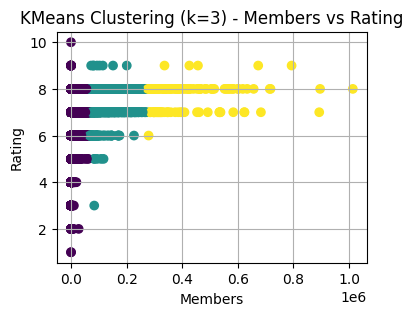

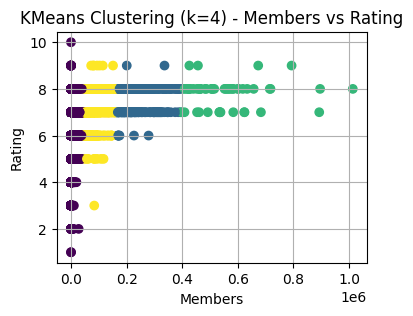

In [92]:
# Plotting the results
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_kmeans3_members_ratings['members'], df_clustering_kmeans3_members_ratings['rating'], c=df_clustering_kmeans3_members_ratings['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=3) - Members vs Rating")
plt.grid(True)
plt.show()


# Plotting the results
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_kmeans4_members_ratings['members'], df_clustering_kmeans4_members_ratings['rating'], c=df_clustering_kmeans4_members_ratings['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=4) - Members vs Rating")
plt.grid(True)
plt.show()


 Clusters are very horizontally stretched, showing KMeans is forcing partitioning based on distance rather than shape. When k = 4, the fourth cluster seems to slightly refine the mid-popularity group

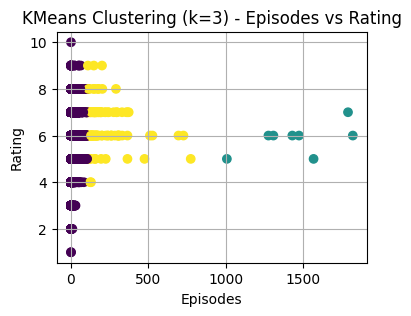

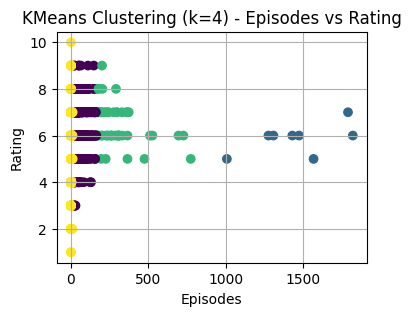

In [93]:
# Plotting the results
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_kmeans3_episodes_ratings['episodes'], df_clustering_kmeans3_episodes_ratings['rating'], c=df_clustering_kmeans3_episodes_ratings['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=3) - Episodes vs Rating")
plt.grid(True)
plt.show()

# Plot the result
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_kmeans4_episodes_ratings['episodes'], df_clustering_kmeans4_episodes_ratings['rating'], c=df_clustering_kmeans4_episodes_ratings['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("KMeans Clustering (k=4) - Episodes vs Rating")
plt.grid(True)
plt.show()

The majority of anime are short-form (12-24 episodes), creating a dense vertical wall near the Y-axis. Here, jmore k doesn't bring significant interpretability.



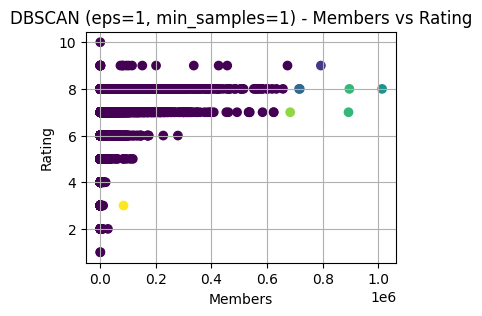

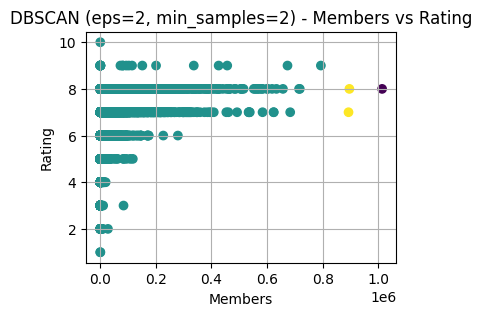

In [94]:
# Plot
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_dbscan_1_1_members_ratings['members'], df_clustering_dbscan_1_1_members_ratings['rating'], c=df_clustering_dbscan_1_1_members_ratings['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=1, min_samples=1) - Members vs Rating")
plt.grid(True)
plt.show()

# Plot
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_dbscan_2_2_members_ratings['members'], df_clustering_dbscan_2_2_members_ratings['rating'], c=df_clustering_dbscan_2_2_members_ratings['cluster'])
plt.xlabel("Members")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=2, min_samples=2) - Members vs Rating")
plt.grid(True)
plt.show()


In the top graph, it produces multiple small clusters, but one dominant cluster (likely cluster 0) contains the majority. It is similar for the second one. However, it seems the DBScan is not very useful here because it's failing to form meaningful distinct clusters.

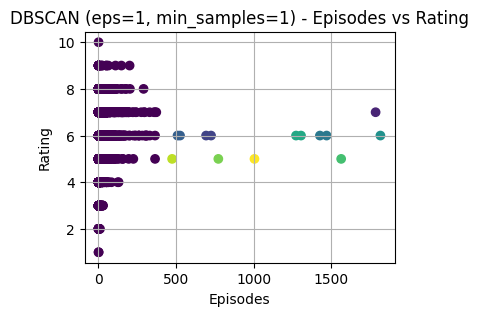

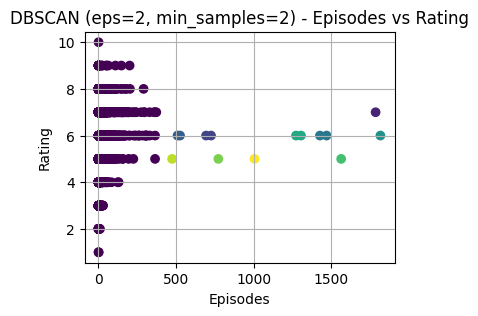

In [95]:
# Plot results
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_dbscan_1_1_episodes_ratings['episodes'], df_clustering_dbscan_1_1_episodes_ratings['rating'], c=df_clustering_dbscan_1_1_episodes_ratings['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=1, min_samples=1) - Episodes vs Rating")
plt.grid(True)
plt.show()

# Plot results
plt.figure(figsize=(4, 3))
plt.scatter(df_clustering_dbscan_2_2_episodes_ratings['episodes'], df_clustering_dbscan_2_2_episodes_ratings['rating'], c=df_clustering_dbscan_2_2_episodes_ratings['cluster'])
plt.xlabel("Episodes")
plt.ylabel("Rating")
plt.title("DBSCAN (eps=2, min_samples=2) - Episodes vs Rating")
plt.grid(True)
plt.show()

Simiarly to the previous DBScan run, there is a majority cluster. However, we do see some far distant clusters as outliers.

My conclusion is that KMeans provide more meaningful separation for visualization and clustering than DBScan, because there are more balanced and distinct clusters.

# Study 3 – Content-Based Recommendation System

A heuristic is like a custom formula that combines several features (columns) to decide how similar two anime are. For example, I want to find an anime similar to X. So I'm going to compare X with the other anime in the dataset and sort the results.

Because we are combining columns now, the scales aren't the same so we need to normalize the columns. In the previous studies we are quering individual columns so we didn't need to normalize.

In [96]:
df_anime_copy = df_anime.copy()

In [97]:
genre_cols = [col for col in df_anime_copy.columns if col.startswith("genre_")]
print(genre_cols)

['genre_Seinen', 'genre_Martial Arts', 'genre_Game', 'genre_Yuri', 'genre_Mecha', 'genre_Shounen', 'genre_Parody', 'genre_Sci-Fi', 'genre_Psychological', 'genre_Shoujo Ai', 'genre_Hentai', 'genre_Magic', 'genre_Harem', 'genre_Dementia', 'genre_Adventure', 'genre_Thriller', 'genre_Romance', 'genre_Fantasy', 'genre_Samurai', 'genre_Military', 'genre_Sports', 'genre_Space', 'genre_Yaoi', 'genre_Shounen Ai', 'genre_Ecchi', 'genre_Action', 'genre_Kids', 'genre_Slice of Life', 'genre_Comedy', 'genre_Historical', 'genre_Shoujo', 'genre_Police', 'genre_Drama', 'genre_Super Power', 'genre_Music', 'genre_Horror', 'genre_Demons', 'genre_Supernatural', 'genre_Vampire', 'genre_Cars', 'genre_Josei', 'genre_School', 'genre_Mystery']


In [98]:
# Normalize numerical features
def normalize_column(df, column):
    scaler = MinMaxScaler()
    return scaler.fit_transform(df[[column]]).flatten()

In [99]:
df_anime_copy['norm_episodes'] = normalize_column(df_anime, 'episodes')
df_anime_copy['norm_rating'] = normalize_column(df_anime, 'rating')
df_anime_copy['norm_members'] = normalize_column(df_anime, 'members')
df_anime_copy.head()

,anime_id,name,episodes,rating,members,type_Movie,type_Music,type_ONA,type_OVA,type_Special,...,genre_Demons,genre_Supernatural,genre_Vampire,genre_Cars,genre_Josei,genre_School,genre_Mystery,norm_episodes,norm_rating,norm_members
0,32281,Kimi no Na wa.,1,9,200630,1,0,0,0,0,...,0,1,0,0,0,1,0,0.000000,0.888889,0.197872
1,5114,Fullmetal Alchemist: Brotherhood,64,9,793665,0,0,0,0,0,...,0,0,0,0,0,0,0,0.034673,0.888889,0.782770
2,28977,Gintama°,51,9,114262,0,0,0,0,0,...,0,0,0,0,0,0,0,0.027518,0.888889,0.112689
3,9253,Steins;Gate,24,9,673572,0,0,0,0,0,...,0,0,0,0,0,0,0,0.012658,0.888889,0.664325
4,9969,Gintama&#039;,51,9,151266,0,0,0,0,0,...,0,0,0,0,0,0,0,0.027518,0.888889,0.149186


### Heuristic A: Genre + Episodes + Rating

| Attribute          | Measure    |    Description   |
|:-------------:|:-----------------:|:-----------------:|
| genre    | Jaccard Similarity         | Measures overlap of genre tags  |
| episodes| Manhattan Distance         | Measures difference in length |
| rating | Euclidean Distance         |  Measures difference in user rating |

The total similarity score combines all three, with lower scores indicating greater similarity.

In [100]:
def jaccard_similarity(row1, row2):
    intersection = ((row1 == 1) & (row2 == 1)).sum()
    union = ((row1 == 1) | (row2 == 1)).sum()
    return intersection / union if union != 0 else 0

In [101]:
def heuristic_a(reference_row, df_filtered):
    # Step 1: Extract features from the reference anime
    ref_genres = reference_row[genre_cols].values.astype(bool)
    ref_ep = reference_row['norm_episodes']
    ref_rating = reference_row['norm_rating']

    results = []
    # Loop over all other anime to calculate similarity
    for idx, row in df_filtered.iterrows():
        genre_sim = jaccard_similarity(ref_genres, row[genre_cols].values.astype(bool))

        # Manhattan distance (1d data so euclidean is the same as Manhattan)
        ep_dist = abs(ref_ep - row['norm_episodes'])
        # Euclidean distance
        rating_dist = abs(ref_rating - row['norm_rating'])

        # Combine all 3 into one score (lower = more similar)
        # Since Jaccard is similarity (higher is better), we subtract it from 1
        total_score = (1 - genre_sim) + ep_dist + rating_dist

        # Save the anime name and its total similarity score
        results.append([row['name'], total_score])

    # Sort the results by similarity score (ascending)
    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            if results[i][1] > results[j][1]:
                # Swap if the later one is more similar (lower score)
                results[i], results[j] = results[j], results[i]

    # Step 4: Return the Top 10 most similar anime
    return results[:10]

In [102]:
# Show me anime similar to "Death Note”
target_title = "Death Note"

# Extract the reference anime row
reference_row = df_anime_copy[df_anime_copy['name'] == target_title].iloc[0]
df_anime_filtered = df_anime_copy[df_anime_copy['name'] != target_title].copy()

top10 = heuristic_a(reference_row, df_anime_filtered)
for rank, (name, score) in enumerate(top10, 1):
    print(f"{rank}. {name} — Score: {score:.4f}")

1. Death Note Rewrite — Score: 0.1304
2. Higurashi no Naku Koro ni Kai — Score: 0.2072
3. Mousou Dairinin — Score: 0.2910
4. Higurashi no Naku Koro ni — Score: 0.3394
5. Mirai Nikki (TV) — Score: 0.4346
6. Higurashi no Naku Koro ni Rei — Score: 0.4621
7. Jigoku Shoujo Futakomori — Score: 0.5061
8. Boku dake ga Inai Machi — Score: 0.5138
9. Jigoku Shoujo Mitsuganae — Score: 0.5172
10. Kara no Kyoukai 4: Garan no Dou — Score: 0.5198


In [103]:
# Show me anime similar to "Naruto”
target_title = "Naruto"

# Extract the reference anime row
reference_row = df_anime_copy[df_anime_copy['name'] == target_title].iloc[0]
df_anime_filtered = df_anime_copy[df_anime_copy['name'] != target_title].copy()

top10 = heuristic_a(reference_row, df_anime_filtered)
for rank, (name, score) in enumerate(top10, 1):
    print(f"{rank}. {name} — Score: {score:.4f}")

1. Naruto: Shippuuden — Score: 0.1200
2. Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi — Score: 0.1205
3. Naruto x UT — Score: 0.1205
4. Naruto: Shippuuden Movie 4 - The Lost Tower — Score: 0.1205
5. Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono — Score: 0.1205
6. Naruto Shippuuden: Sunny Side Battle — Score: 0.1205
7. Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!! — Score: 0.1205
8. Boruto: Naruto the Movie — Score: 0.2316
9. Katekyo Hitman Reborn! — Score: 0.3205
10. Dragon Ball Kai — Score: 0.3534


In [104]:
# Show me anime similar to "Shingeki no Kyojin”
target_title = "Shingeki no Kyojin"

# Extract the reference anime row
reference_row = df_anime_copy[df_anime_copy['name'] == target_title].iloc[0]
df_anime_filtered = df_anime_copy[df_anime_copy['name'] != target_title].copy()

top10 = heuristic_a(reference_row, df_anime_filtered)
for rank, (name, score) in enumerate(top10, 1):
    print(f"{rank}. {name} — Score: {score:.4f}")

1. Shingeki no Kyojin OVA — Score: 0.1232
2. Shingeki no Kyojin Movie 2: Jiyuu no Tsubasa — Score: 0.1243
3. Shingeki no Kyojin Movie 1: Guren no Yumiya — Score: 0.1243
4. Shingeki no Kyojin Season 2 — Score: 0.2349
5. Shingeki no Kyojin: Ano Hi Kara — Score: 0.2354
6. One Piece — Score: 0.2984
7. One Piece: Episode of Nami - Koukaishi no Namida to Nakama no Kizuna — Score: 0.2989
8. One Piece: Episode of Merry - Mou Hitori no Nakama no Monogatari — Score: 0.2989
9. Saint Seiya: Meiou Hades Elysion-hen — Score: 0.3216
10. One Piece: Episode of Sabo - 3 Kyoudai no Kizuna Kiseki no Saikai to Uketsugareru Ishi — Score: 0.4100


### Heuristic B: Members + Title + Rating

| Attribute          | Measure    |    Description   |
|:-------------:|:-----------------:|:-----------------:|
| members    | Euclidean Distance         | Measures popularity proximity  |
| name| Levenshtein Distance         | Captures similar naming |
| rating | Euclidean Distance         |  Measures difference in user rating |

This one focuses on popularity + name relevance + quality.

In [105]:
def heuristic_b(reference_row, df_filtered):
    # Step 1: Extract features
    ref_members = reference_row['norm_members']
    ref_title = reference_row['name']
    ref_rating = reference_row['norm_rating']

    results = []

    # Step 2: Loop through all other anime
    for idx, row in df_filtered.iterrows():
        members_dist = abs(ref_members - row['norm_members'])

        # Levenshtein distance normalized by max string length
        lev_dist = Levenshtein.distance(ref_title, row['name'])
        max_len = max(len(ref_title), len(row['name']), 1)
        title_dist = lev_dist / max_len

        rating_dist = abs(ref_rating - row['norm_rating'])

        total_score = members_dist + title_dist + rating_dist

        results.append([row['name'], total_score])

    # Step 3: Sort the results
    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            if results[i][1] > results[j][1]:
                results[i], results[j] = results[j], results[i]

    # Step 4: Return Top 10
    return results[:10]

In [106]:
# Show me anime similar to "Death Note”
target_title = "Death Note"

# Extract the reference anime row
reference_row = df_anime_copy[df_anime_copy['name'] == target_title].iloc[0]
df_anime_filtered = df_anime_copy[df_anime_copy['name'] != target_title].copy()

top10 = heuristic_b(reference_row, df_anime_filtered)
for rank, (name, score) in enumerate(top10, 1):
    print(f"{rank}. {name} — Score: {score:.4f}")

1. Shingeki no Kyojin — Score: 0.9494
2. Death Parade — Score: 1.0380
3. Sword Art Online — Score: 1.0428
4. No Game No Life — Score: 1.0726
5. Fullmetal Alchemist: Brotherhood — Score: 1.1096
6. Angel Beats! — Score: 1.1254
7. Code Geass: Hangyaku no Lelouch — Score: 1.1334
8. Steins;Gate — Score: 1.1741
9. Tokyo Ghoul — Score: 1.2086
10. Mirai Nikki (TV) — Score: 1.2268


In [107]:
# Show me anime similar to "Naruto”
target_title = "Naruto"

# Extract the reference anime row
reference_row = df_anime_copy[df_anime_copy['name'] == target_title].iloc[0]
df_anime_filtered = df_anime_copy[df_anime_copy['name'] != target_title].copy()

top10 = heuristic_b(reference_row, df_anime_filtered)
for rank, (name, score) in enumerate(top10, 1):
    print(f"{rank}. {name} — Score: {score:.4f}")

1. Naruto: Shippuuden — Score: 0.8143
2. Toradora! — Score: 0.9377
3. No Game No Life — Score: 0.9910
4. Fairy Tail — Score: 1.0085
5. Ao no Exorcist — Score: 1.0267
6. Noragami — Score: 1.0267
7. Charlotte — Score: 1.0347
8. Durarara!! — Score: 1.0362
9. Sword Art Online II — Score: 1.0381
10. Nisekoi — Score: 1.0454


In [108]:
# Show me anime similar to "Shingeki no Kyojin”
target_title = "Shingeki no Kyojin"

# Extract the reference anime row
reference_row = df_anime_copy[df_anime_copy['name'] == target_title].iloc[0]
df_anime_filtered = df_anime_copy[df_anime_copy['name'] != target_title].copy()

top10 = heuristic_b(reference_row, df_anime_filtered)
for rank, (name, score) in enumerate(top10, 1):
    print(f"{rank}. {name} — Score: {score:.4f}")

1. Code Geass: Hangyaku no Lelouch — Score: 0.9205
2. Sword Art Online — Score: 0.9475
3. Death Note — Score: 0.9494
4. Angel Beats! — Score: 0.9538
5. Shokugeki no Souma — Score: 0.9842
6. Shinsekai yori — Score: 1.0440
7. Tokyo Ghoul — Score: 1.0521
8. Shingeki no Kyojin OVA — Score: 1.0575
9. Code Geass: Hangyaku no Lelouch R2 — Score: 1.0836
10. Fullmetal Alchemist: Brotherhood — Score: 1.0873


Heuristic A perform better than Heuristic B because the scores overall are lower (lower scores indicate higher similarity). For example, in heuristic B, it fails to recommend "Death Note Rewrite" for target_anime = "Death Note". In heuristic B, it fails to recommend "Boruto" when target_anime = "Naruto". These are very close animes. Qualitatively speaking, the scores in B are higher (most of them close to 1), while the socres in A are closer to 0.1 indicating higher similarity


# Study 4

In [ ]:
# from scipy.sparse.linalg import svds
# from sklearn.metrics import mean_squared_error


In [33]:

df_rating = df_rating[df_rating['rating'] != -1]    # disregarding entries with -1 rating as they're not going to be useful by removing them
df_rating = df_rating.groupby(['user_id', 'anime_id']).agg({'rating': 'mean'}).reset_index()        # aggregating duplicates using the mean
utility_matrix = df_rating.pivot(index='user_id', columns='anime_id', values='rating')              # building the utility matrix Rui
utility_matrix = utility_matrix.fillna(0)           # filling the empty/nan animes with 0
R = utility_matrix.values                           # converting to array for matrix factorization


In [34]:
#setting the latent dimensions
# latent_dimensions = 3   # test 1
# latent_dimensions = 30  # test 2
latent_dimensions = 50  # test 3
# latent_dimensions = 80  # test 4

U, sigma, Vt = svds(R, k=latent_dimensions) #decomposing
sigma = np.diag(sigma)                      #converting to matrix
P = np.dot(U, sigma)                        #approximating the utility matrix R
Q = Vt
predicted_ratings = np.dot(P, Q)            #reconstructing prediction matrix
predicted_ratings_df = pd.DataFrame(predicted_ratings, index=utility_matrix.index, columns=utility_matrix.columns) #converting back to df with user_id's and anime_id's

In [35]:
def recommend_anime(user_id, top_n=10):
    user_ratings = predicted_ratings_df.loc[user_id]                            #the users predicted ratings
    seen_anime = df_rating[df_rating['user_id'] == user_id]['anime_id'].values  #the already seen animes
    recommendations = user_ratings.drop(index=seen_anime).sort_values(ascending=False).head(top_n)          #recommending top rated unseen animes
    recommended_anime = df_anime[df_anime['anime_id'].isin(recommendations.index)][['anime_id', 'name']]    #the animes names from the df

    return recommended_anime    #returning the recommendations


# Simulating 3 requests
# req 1
print("Request 1: Recommended anime for User 1")
print(recommend_anime(user_id=1))
# req 2
print("\nRequest 2: Recommended anime for User 2")
print(recommend_anime(user_id=2))
# req 3
print("\nRequest 3: Recommended anime for User 3")
print(recommend_anime(user_id=3))


Request 1: Recommended anime for User 1
      anime_id                      name
86       16498        Shingeki no Kyojin
118      19815           No Game No Life
159       6547              Angel Beats!
288       6702                Fairy Tail
445      10620          Mirai Nikki (TV)
760        226                Elfen Lied
830      10793              Guilty Crown
2132     21881       Sword Art Online II
2533      4214  Rosario to Vampire Capu2
2895      2993        Rosario to Vampire

Request 2: Recommended anime for User 2
      anime_id                         name
6        11061       Hunter x Hunter (2011)
14       28891      Haikyuu!! Second Season
43       20583                    Haikyuu!!
58       24415  Kuroko no Basket 3rd Season
72       16894  Kuroko no Basket 2nd Season
159       6547                 Angel Beats!
288       6702                   Fairy Tail
443      16916    Kuroko no Basket: Tip Off
608      22265        Free!: Eternal Summer
1115     18507              

### Qualitative Evalutaion

In [36]:
sample_users = [1, 2, 3]    #testing the same users for their top animes

for user_id in sample_users:
    print(f"\nUser {user_id}'s Top Rated Anime:")
    top_rated = df_rating[df_rating['user_id'] == user_id].sort_values(by='rating', ascending=False).head(5)
    print(df_anime[df_anime['anime_id'].isin(top_rated['anime_id'])][['anime_id', 'name']])

    print(f"\nRecommended Anime for User {user_id}:")
    print(recommend_anime(user_id=user_id))


User 1's Top Rated Anime:
      anime_id                    name
724      15451     High School DxD New
804      11757        Sword Art Online
1057     11617         High School DxD
1709      8074  Highschool of the Dead

Recommended Anime for User 1:
      anime_id                      name
86       16498        Shingeki no Kyojin
118      19815           No Game No Life
159       6547              Angel Beats!
288       6702                Fairy Tail
445      10620          Mirai Nikki (TV)
760        226                Elfen Lied
830      10793              Guilty Crown
2132     21881       Sword Art Online II
2533      4214  Rosario to Vampire Capu2
2895      2993        Rosario to Vampire

User 2's Top Rated Anime:
     anime_id              name
122     11771  Kuroko no Basket

Recommended Anime for User 2:
      anime_id                         name
6        11061       Hunter x Hunter (2011)
14       28891      Haikyuu!! Second Season
43       20583                    Haikyuu!

### Quantitative Evaluation

In [37]:
#splitting by 10% the gold standart
df_rating_sampled = df_rating.sample(frac=0.1, random_state=42)     # 10% of ratings
df_rating_train = df_rating.drop(df_rating_sampled.index)           # 90% remaining

#computing matrix without the gold standart
utility_matrix_train = df_rating_train.pivot(index='user_id', columns='anime_id', values='rating').fillna(0)
R_train = utility_matrix_train.values

U_train, sigma_train, Vt_train = svds(R_train, k=latent_dimensions)
sigma_train = np.diag(sigma_train)
P_train = np.dot(U_train, sigma_train)
Q_train = Vt_train
predicted_ratings_train = np.dot(P_train, Q_train)
predicted_ratings_df_train = pd.DataFrame(predicted_ratings_train, index=utility_matrix_train.index, columns=utility_matrix_train.columns)

#Evaluating with the MSE
true_ratings = df_rating_sampled.set_index(['user_id', 'anime_id'])['rating']
predicted_ratings = true_ratings.copy()

for (user, anime) in true_ratings.index:
    if user in predicted_ratings_df_train.index and anime in predicted_ratings_df_train.columns:
        predicted_ratings.loc[(user, anime)] = predicted_ratings_df_train.loc[user, anime]
    else:
        predicted_ratings.loc[(user, anime)] = np.nan  #if missing

#removing missing values for MSE
common_idx = true_ratings.index.intersection(predicted_ratings.dropna().index)
mse_score = mean_squared_error(true_ratings.loc[common_idx], predicted_ratings.loc[common_idx])

print(f"MSE between predicted and actual ratings: {mse_score:.4f}")

MSE between predicted and actual ratings: 34.3922


In [38]:
#Evaluating with:   Precision@5, Precision@10
def getPrecision_K(true_ratings, predicted_ratings, k):
    precision_scores = []
    for user in true_ratings.index.get_level_values(0).unique():
        if user not in predicted_ratings_df_train.index:
            continue
        true_items = set(true_ratings.loc[user][true_ratings.loc[user] >= 4].index)
        if not true_items:
            continue
        predicted_top_k = set(predicted_ratings_df_train.loc[user].nlargest(k).index)
        precision_scores.append(len(true_items & predicted_top_k) / k)

    return np.mean(precision_scores)

#MRR
def getMRR(true_ratings, predicted_ratings):
    rr_scores = []
    for user in true_ratings.index.get_level_values(0).unique():
        if user not in predicted_ratings_df_train.index:
            continue
        true_items = set(true_ratings.loc[user][true_ratings.loc[user] >= 4].index)
        ranked_predictions = predicted_ratings_df_train.loc[user].sort_values(ascending=False).index.tolist()
        for i, anime in enumerate(ranked_predictions):
            if anime in true_items:
                rr_scores.append(1 / (i + 1))
                break
        else:
            rr_scores.append(0)
    return np.mean(rr_scores)

In [39]:
p_5  = getPrecision_K(true_ratings, predicted_ratings, k=5)
p_10 = getPrecision_K(true_ratings, predicted_ratings, k=10)
mrr_score = getMRR(true_ratings, predicted_ratings)

print(f"Precision@5 : {p_5:.4f}")
print(f"Precision@10: {p_10:.4f}")
print(f"MRR         : {mrr_score:.4f}")


Precision@5 : 0.0244
Precision@10: 0.0325
MRR         : 0.0942


Evaluation Results:  

- Qualitative Results:  
*  
| User No| Top Rated Animes |
|:-------|:----------------|
| 1      | 724      15451     High School DxD New                               |
| 1      | 804      11757        Sword Art Online                               |
| 1      | 1057     11617         High School DxD                               |
| 1      | 1709      8074  Highschool of the Dead                               |
| 2      | 122     11771  Kuroko no Basket                                      |
| 3      | 40       1535                                         Death Note     |
| 3      | 57       9989  Ano Hi Mita Hana no Namae wo Bokutachi wa Mada...     |
| 3      | 72      16894                        Kuroko no Basket 2nd Season     |
| 3      | 122     11771                                   Kuroko no Basket     |
| 3      | 616     20159                                Pokemon: The Origin     |
*  
| User No| Recommended Animes |
|:-------|:----------------|
| 1  | 16498 Shingeki no Kyojin |
|| 19815 No Game No Life        |
|| 6547 Angel Beats!            |
|| 6702 Fairy Tail              |
|| 10620 Mirai Nikki (TV)       |
|| 226 Elfen Lied               |
|| 10793 Guilty Crown           |
|| 21881 Sword Art Online II    |
|| 4214 Rosario to Vampire Capu2|
|| 2993 Rosario to Vampire      |
| 2  | 11061 Hunter x Hunter (2011)     |
|| 28891 Haikyuu!! Second Season        |
|| 20583 Haikyuu!!                      |
|| 24415 Kuroko no Basket 3rd Season    |
|| 16894 Kuroko no Basket 2nd Season    |
|| 6547 Angel Beats!                    |
|| 6702 Fairy Tail                      |
|| 16916 Kuroko no Basket: Tip Off      |
|| 22265 Free!: Eternal Summer          |
|| 18507 Free!                          |
| 3  | 11061 Hunter x Hunter (2011)                 |
|| 30276 One Punch Man                              |
|| 22535 Kiseijuu: Sei no Kakuritsu                 |
|| 121 Fullmetal Alchemist                          |
|| 223 Dragon Ball                                  |
|| 269 Bleach                                       |
|| 528 Pokemon: Mewtwo no Gyakushuu                 |
|| 481 Yu☆Gi☆Oh! Duel Monsters                     |
|| 1117 Pokemon: Maboroshi no Pokemon Lugia Bakutan |
|| 1118 Pokemon: Kesshoutou no Teiou Entei          |

- Quantitative Results:  
*  
| Metric | Result |
|:-------|:------:|
|Precision@5    | 0.0244|
|Precision@10   | 0.0325|
|MRR            | 0.0942|
|MSE between predicted and actual ratings| 34.3922|


- The results of the model show;  
    - High MSE suggest poor rating predictions
    - Low P@5 and P@10 suggest the recommended animes do not very successfully match the user's prefereces
    - MRR results show the more relevant items were ranked lower in suggestions
    - Overall, the results show that the model would need further fine tuning to optimize the search recommendations.

# References
- https://www.datacamp.com/tutorial/python-boxplots    
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.jaccard_score.html    
- https://pypi.org/project/python-Levenshtein/    
- https://www.w3schools.com/python/matplotlib_scatter.asp    
- https://medium.com/data-science/recommendation-system-matrix-factorization-d61978660b4b  
- https://medium.com/@evelyn.eve.9512/collaborative-filtering-in-recommender-system-an-overview-38dfa8462b61  
- https://medium.com/@denizturhanlar2913/tavsiye-sistemleri-recommendation-systems-a4970c345e0b  
- https://medium.com/@beyzatas2580/recommendation-systems-ea6d6b720872  
- https://docs.scipy.org/doc/scipy/reference/sparse.linalg.html  
- https://scikit-learn.org/0.16/modules/generated/sklearn.metrics.mean_squared_error.html  


